In [1]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [5]:
# Load cleaned dataset
df = pd.read_csv(
    "outputs/space_missions_feature_engineered.csv",
    
)


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4503 entries, 0 to 4502
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              4503 non-null   object 
 1   Location             4503 non-null   object 
 2   Date                 4503 non-null   object 
 3   Time                 4503 non-null   object 
 4   Rocket               4503 non-null   object 
 5   Mission              4503 non-null   object 
 6   RocketStatus         4503 non-null   object 
 7   Price                4503 non-null   float64
 8   MissionStatus        4503 non-null   object 
 9   Launch_DateTime      4503 non-null   object 
 10  Launch_Year          4503 non-null   int64  
 11  Launch_Month         4503 non-null   int64  
 12  Launch_Month_Name    4503 non-null   object 
 13  Launch_Quarter       4503 non-null   int64  
 14  Launch_Day           4503 non-null   int64  
 15  Launch_Day_Name      4503 non-null   o

In [7]:
df["Time"].head()

0    19:28:00
1     2:30:00
2    16:44:00
3     3:48:00
4     7:33:00
Name: Time, dtype: object

In [8]:
# Convert Launch_DateTime to datetime

df["Launch_DateTime"] = pd.to_datetime(df["Launch_DateTime"])

In [9]:
# Check dataset shape

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 4503
Columns : 27


In [10]:
# Check missing values

df.isnull().sum()

Company                0
Location               0
Date                   0
Time                   0
Rocket                 0
Mission                0
RocketStatus           0
Price                  0
MissionStatus          0
Launch_DateTime        0
Launch_Year            0
Launch_Month           0
Launch_Month_Name      0
Launch_Quarter         0
Launch_Day             0
Launch_Day_Name        0
Launch_Week            0
Launch_Decade          0
Launch_Hour            0
Launch_Minute          0
Launch_Second          0
Launch_Period          0
Country                0
Launch_Site            0
Price_Category         0
Mission_Result         0
Rocket_Availability    0
dtype: int64

In [11]:
# Display column names

df.columns

Index(['Company', 'Location', 'Date', 'Time', 'Rocket', 'Mission',
       'RocketStatus', 'Price', 'MissionStatus', 'Launch_DateTime',
       'Launch_Year', 'Launch_Month', 'Launch_Month_Name', 'Launch_Quarter',
       'Launch_Day', 'Launch_Day_Name', 'Launch_Week', 'Launch_Decade',
       'Launch_Hour', 'Launch_Minute', 'Launch_Second', 'Launch_Period',
       'Country', 'Launch_Site', 'Price_Category', 'Mission_Result',
       'Rocket_Availability'],
      dtype='object')

In [12]:
# Preview the dataset

df.head()


,Company,Location,Date,Time,Rocket,Mission,RocketStatus,Price,MissionStatus,Launch_DateTime,Launch_Year,Launch_Month,Launch_Month_Name,Launch_Quarter,Launch_Day,Launch_Day_Name,Launch_Week,Launch_Decade,Launch_Hour,Launch_Minute,Launch_Second,Launch_Period,Country,Launch_Site,Price_Category,Mission_Result,Rocket_Availability
0,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",04-10-1957,19:28:00,Sputnik 8K71PS,Sputnik-1,Retired,108.84232,Success,1957-10-04 19:28:00,1957,10,October,4,4,Friday,40,1950,19,28,0,Evening,Kazakhstan,Site 1/5,Premium,Successful,Retired
1,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",03-11-1957,2:30:00,Sputnik 8K71PS,Sputnik-2,Retired,108.84232,Success,1957-11-03 02:30:00,1957,11,November,4,3,Sunday,44,1950,2,30,0,Night,Kazakhstan,Site 1/5,Premium,Successful,Retired
2,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",06-12-1957,16:44:00,Vanguard,Vanguard TV3,Retired,108.84232,Failure,1957-12-06 16:44:00,1957,12,December,4,6,Friday,49,1950,16,44,0,Afternoon,USA,LC-18A,Premium,Unsuccessful,Retired
3,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA",01-02-1958,3:48:00,Juno I,Explorer 1,Retired,108.84232,Success,1958-02-01 03:48:00,1958,2,February,1,1,Saturday,5,1950,3,48,0,Night,USA,LC-26A,Premium,Successful,Retired
4,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",05-02-1958,7:33:00,Vanguard,Vanguard TV3BU,Retired,108.84232,Failure,1958-02-05 07:33:00,1958,2,February,1,5,Wednesday,6,1950,7,33,0,Morning,USA,LC-18A,Premium,Unsuccessful,Retired


In [13]:
# Check unique mission status values

df["MissionStatus"].unique()

array(['Success', 'Failure', 'Partial Failure', 'Prelaunch Failure'],
      dtype=object)

In [14]:
# Count unique mission status values

df["MissionStatus"].nunique()


4

In [15]:
# Frequency distribution

mission_count = df["MissionStatus"].value_counts()

mission_count

MissionStatus
Success              4076
Failure               318
Partial Failure       107
Prelaunch Failure       2
Name: count, dtype: int64

In [16]:
# Percentage distribution

round(
    df["MissionStatus"].value_counts(normalize=True) * 100,
    2
)

MissionStatus
Success              90.52
Failure               7.06
Partial Failure       2.38
Prelaunch Failure     0.04
Name: proportion, dtype: float64

In [17]:
# Summary table

mission_summary = pd.DataFrame({
    "Count": df["MissionStatus"].value_counts(),
    "Percentage": round(
        df["MissionStatus"].value_counts(normalize=True) * 100,
        2
    )
})

mission_summary

,Count,Percentage
MissionStatus,,
Success,4076,90.52
Failure,318,7.06
Partial Failure,107,2.38
Prelaunch Failure,2,0.04


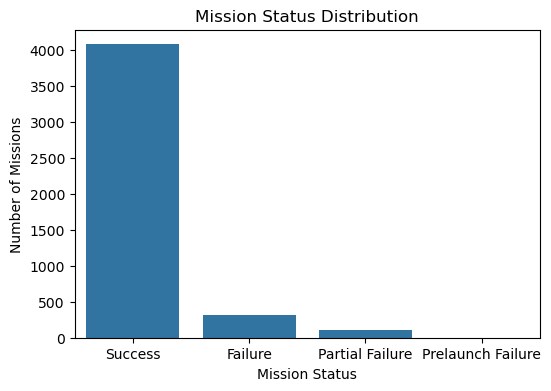

In [18]:
# Visualize mission status distribution

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="MissionStatus"
)

plt.title("Mission Status Distribution")
plt.xlabel("Mission Status")
plt.ylabel("Number of Missions")

plt.show()

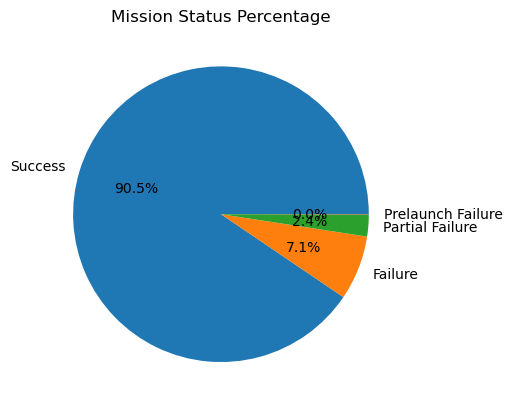

In [19]:
# Visualize mission status percentage

mission_summary["Percentage"].plot(
    kind="pie",
    autopct="%1.1f%%",
    ylabel=""
)

plt.title("Mission Status Percentage")

plt.show()